# Chapter 4: Training Models

## 1. Linear Regression Model

In [1]:
import numpy as np

rng = np.random.default_rng(seed=42)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3 * X + rng.standard_normal((m, 1))

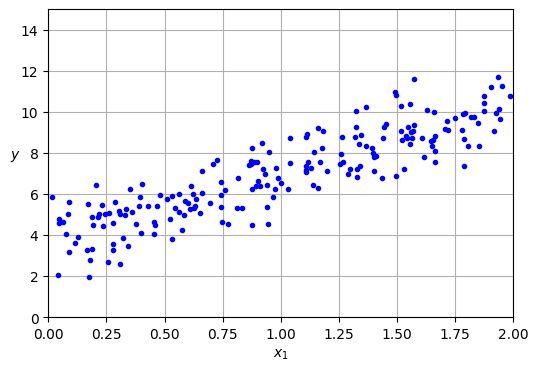

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.grid()
plt.axis([0, 2, 0, 15])
plt.show()

In [3]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.69084138],
       [3.32960458]])

In [4]:
# Making new predictions with the best theta
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_predict = X_new_b @ theta_best
y_predict

array([[ 3.69084138],
       [10.35005055]])

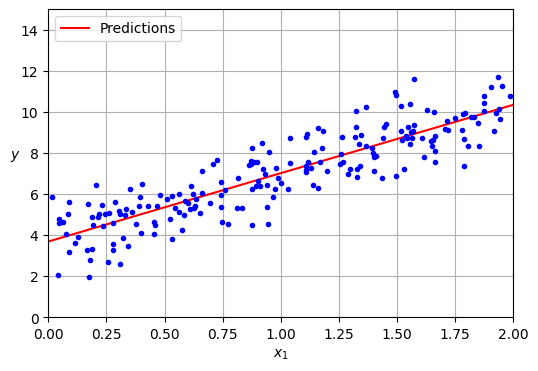

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(X_new, y_predict, "r-", label='Predictions')
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.legend(loc='upper left')
plt.show()

In [6]:
# Now implementing Linear Regression with Scikit-Learn
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([3.69084138]), array([[3.32960458]]))

.intercept_ is bias term and .coef_ are feature weights.

In [7]:
lin_reg.predict(X_new)

array([[ 3.69084138],
       [10.35005055]])

LinearRegression is based on lstsq, which "least squares" 

In [8]:
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.69084138],
       [3.32960458]])

$\mathbf{X}^+\mathbf{y}$, where $\mathbf{X}^+$ is the pseudo inverse of X

In [9]:
np.linalg.pinv(X_b) @ y

array([[3.69084138],
       [3.32960458]])

## 2. Batch Gradient Descent

In [10]:
eta = 0.1 # learning rate
n_epochs = 1000
m = len(X_b) # number of instances

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

In [11]:
for _ in range(n_epochs):
    gradients = 2 / m * X_b.T @ (X_b @ theta -  y)
    theta = theta - eta * gradients

In [12]:
theta

array([[3.69084138],
       [3.32960458]])

## 3. Stochastic Gradient Descent

Implementing Stochastic Gradient Descent with a simple learning schedule.

In [13]:
n_epochs = 50
t0, t1 = 5, 50 # Learning Schedule Hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

In [14]:
for epoch in range(n_epochs):
    for iteration in range(m):
        random_index = rng.integers(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index :  random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients

In [15]:
theta

array([[3.69826475],
       [3.30748311]])

In [16]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(
    max_iter=1000,
    tol=10e-5,
    n_iter_no_change=100,
    eta0=0.01,
    random_state=42,
    penalty=None
)
sgd_reg.fit(X, y.ravel()) # .ravel because .fit expects 1D targets

,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values must be in the range `[0.0, 1.0]` or can be `None` if`penalty` is not `elasticnet`... versionchanged:: 1.7 `l1_ratio` can be `None` when `penalty` is not ""elasticnet"".",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.0001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.Values must be in the range `[0, inf)`.",0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-insensitive loss functions; only if `loss` is'huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'.For 'huber', determines the threshold at which it becomes lessimportant to get the prediction exactly right.For epsilon-insensitive, any differences between the current predictionand the correct label are ignored if they are less than this threshold.Values must be in the range `[0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [17]:
sgd_reg.intercept_, sgd_reg.coef_

(array([3.68899733]), array([3.33054574]))

## 4. Mini-Batch Gradient Descent

In [21]:
from math import ceil

t0, t1 = 200, 1000
n_epochs = 50
mini_batch_size = 20
n_batches_per_epoch = ceil(m / mini_batch_size)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))

def learning_schedule(t):
    return t0 / (t + t1)

In [24]:
for epoch in range(n_epochs):
    shuffled_indices = rng.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * mini_batch_size
        xi = X_b_shuffled[idx:idx+mini_batch_size]
        yi = y_shuffled[idx:idx+mini_batch_size]
        gradients = 2 / mini_batch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients

In [25]:
theta

array([[3.66094056],
       [3.27857978]])

## 5. Polynomial Regression

In [26]:
# Generating new noisy nonlinear dataset
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

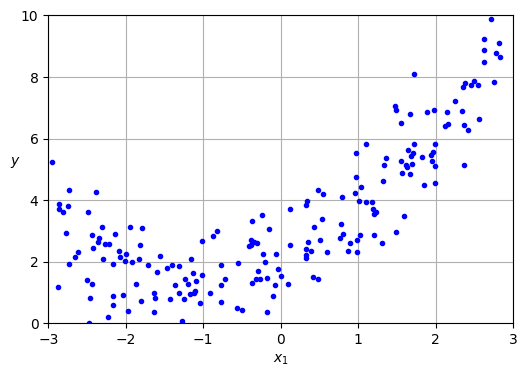

In [28]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, 'b.')
plt.grid()
plt.axis([-3, 3, 0, 10])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.show()

In [30]:
from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X, y)
X[0]

array([1.64373629])

In [31]:
X_poly[0]

array([1.64373629, 2.701869  ])

In [32]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([2.00540719]), array([[1.11022126, 0.50526985]]))

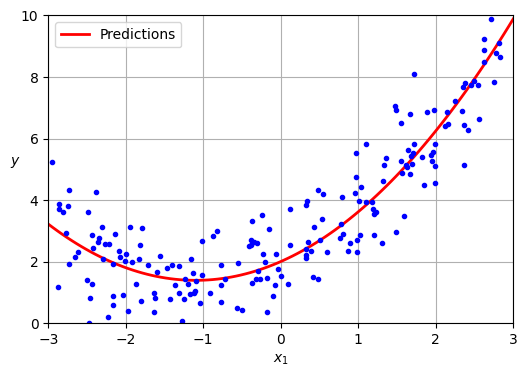

In [34]:
X_new = np.linspace(-3, 3, 100).reshape((100, 1))
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X_new, y_new, "r-", linewidth=2, label='Predictions')
plt.plot(X, y, "b.")
plt.grid()
plt.axis([-3, 3, 0, 10])
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc='upper left')
plt.show()